# MobileNetV2 - Augmented

This notebook will be one of three that will train the models separately before comparing them to select a final model to evaluate using the test set. This is being done because when trying to train all the models in the same notebook, I keep receiving the error "numpy() is only available when eager execution is enabled".

The changes I'll be applying to the datasets:
- Preprocessing (apply to all datasets):
    - Normalizing pixel values to between [0,1]
    - Converting the images to gray scale
    
- Data Augmentation (Training only)
    - Zooming in 
    - Rotating images 
    - Horizontal flip

These augmentation techniques have been shown to greatly boost the metrics on mammogram analysis according to [this paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC9147240/#sec2-jimaging-08-00141). Alongside this, a class weight parameter will also be added to the models to make it so the malignant tumors are taken more into account when training.

# Data Augmentation and Preprocessing

In [1]:
import tensorflow as tf
import keras
from tensorflow.keras import layers, optimizers, metrics, regularizers
from tensorflow import data as tf_data
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.utils import class_weight
from keras.saving import register_keras_serializable

2025-07-30 10:41:19.970378: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-30 10:41:19.971421: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-30 10:41:19.977306: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-30 10:41:19.994758: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753890080.027787    7756 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753890080.03

In [2]:
# Setting some variables 
image_size = (224, 224)
batch_size = 10
seed = 42
    
train_augmentation = keras.Sequential([
    layers.Rescaling(1./255),                       # Normalized pixels to [0,1]
    layers.RandomRotation(0.05),                    # Rotate by 5% of 360 degrees 
    layers.RandomZoom(-0.1, 0.1),                   # Zoom in/out 10%
    layers.RandomFlip("horizontal")                 # Randomly flip images horizontally
])

valid_augmentation = keras.Sequential([
    layers.Rescaling(1./255),])                        # Normalized pixels to [0,1]

train_ds = tf.keras.utils.image_dataset_from_directory(
    "train",
    batch_size=batch_size,
    image_size=image_size,
    color_mode="grayscale",
    shuffle=True,
    seed=seed,
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    "valid",
    batch_size=batch_size,
    image_size=image_size,
    color_mode="grayscale",
    shuffle=False,
    seed=seed,
)

AUTOTUNE = tf.data.AUTOTUNE

# Apply augmentations to training data 
train_ds = train_ds.map(lambda x, y: (train_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

# Apply rescaling to validation data 
valid_ds = valid_ds.map(lambda x, y: (valid_augmentation(x), y), num_parallel_calls=AUTOTUNE)

# Prefetch for performance
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.prefetch(buffer_size=AUTOTUNE)

Found 2372 files belonging to 2 classes.


2025-07-30 10:41:23.219566: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 675 files belonging to 2 classes.


2025-07-30 10:41:24.128163: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


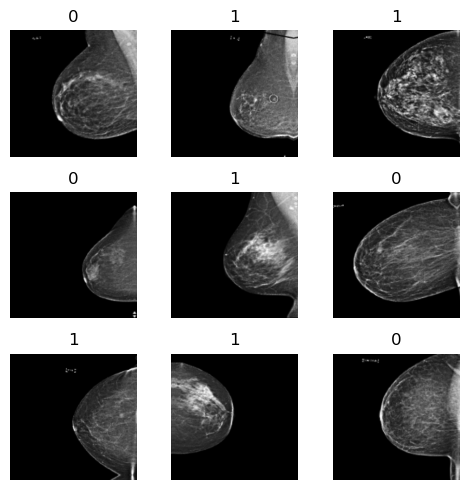

In [3]:
# Check to see augmentations were applied
plt.figure(figsize=(5, 5))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.squeeze(images[i]), cmap="gray")
        plt.title(int(labels[i]))
        plt.axis("off")

plt.tight_layout()
plt.show()

# MobileNetV2 - Augmented

In [4]:
# Convert grayscale to rgb, ensure it is serializable to avoid loading problems later
@register_keras_serializable()
def grayscale_to_rgb(x):
    return tf.image.grayscale_to_rgb(x)

# Updated function that creates transfer models
def make_transfer_model(input_shape, model_name):
    
    # Choose the base model
    if model_name == "MobileNet":
        backbone = keras.applications.MobileNetV2(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )
    elif model_name == "DenseNet":
        backbone = keras.applications.DenseNet121(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )
    elif model_name == "EfficientNet":
        backbone = keras.applications.EfficientNetB0(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )

    backbone.trainable = False

    # Convert grayscale to RGB
    inputs = keras.Input(shape=input_shape)
    x = layers.Lambda(grayscale_to_rgb, output_shape=(224, 224, 3))(inputs)

    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    
    # L2 regularization and dropout layer should help with the overfitting issue
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x) 
    x = layers.Dropout(0.5)(x) 
    outputs = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(0.001))(x)

    return keras.Model(inputs, outputs, name=f"{model_name}_classifier")

In [5]:
# Create the model
MobileNet = make_transfer_model((224,224,1), "MobileNet")

In [6]:
# Calculate the class weights
train_labels = np.stack([y.numpy() for _, y in train_ds.unbatch()])

class_weights = dict(enumerate(class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)))

print(class_weights)

{0: 0.7558954748247291, 1: 1.4769613947696139}


2025-07-30 10:41:28.097346: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
optimizer = optimizers.Adam(learning_rate=0.001)

# Stop training if validation loss doesn't improve for 3 epochs
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

MobileNet.compile(optimizer=optimizer,
                  loss="binary_crossentropy",
                  metrics=[keras.metrics.Recall(name="recall")])

mobile_history = MobileNet.fit(
    train_ds,
    epochs=10,
    callbacks=callbacks,
    validation_data=valid_ds,
    class_weight=class_weights)

Epoch 1/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 67s 258ms/step - loss: 1.0199 - recall: 0.4945 - val_loss: 0.8419 - val_recall: 0.7489
Epoch 2/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 59s 247ms/step - loss: 0.8024 - recall: 0.6057 - val_loss: 0.8183 - val_recall: 0.7489
Epoch 3/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 59s 246ms/step - loss: 0.7749 - recall: 0.5787 - val_loss: 0.7618 - val_recall: 0.6784
Epoch 4/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 59s 247ms/step - loss: 0.7545 - recall: 0.5810 - val_loss: 0.7189 - val_recall: 0.5242
Epoch 5/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 326s 1s/step - loss: 0.7354 - recall: 0.5690 - val_loss: 0.7177 - val_recall: 0.5815
Epoch 6/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 58s 244ms/step - loss: 0.7244 - recall: 0.6357 - val_loss: 0.7158 - val_recall: 0.5859
Epoch 7/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 56s 236ms/step - loss: 0.7208 - recall: 0.6365 - val_loss: 0.7074 - val_recall: 0.6256
Epoch 8/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 55s 229ms/step - loss: 0.7003 - recall: 0.5672 - val_loss: 0.7225 - val_r

In [8]:
# Save model
MobileNet.save("mobilenet.keras")

# Save history
with open("history_mobilenet.pkl", "wb") as f:
    pickle.dump(mobile_history.history, f)